In [1]:
import torch, cv2, os, sys, numpy as np, matplotlib.pyplot as plt
import xarray as xr
import torch.nn.functional as F
import pandas as pd

In [ ]:
# load model
from cbam_unet import net  as net1
from dataset import get_processed_dataset, get_dataloader

#device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# model
model_path = os.path.join('your_model.pth')
model1 = net1(in_channel=3, out_channel=1)  
model1.load_state_dict(torch.load(model_path, map_location='cpu')['model_state_dict'])
model1.eval();

In [3]:
def denormalize_data(data, fake_doy):
    clm_file = os.path.join('predata','clm500m_temp_r486.npz')
    clm = np.load(clm_file)
    clm_mean = clm['clm_mean']
    clm_std = clm['clm_std']

    denorm_data = data * clm_std[fake_doy-1,0] + clm_mean[fake_doy-1,0]
    #print(f"denorm_data shape: {denorm_data.shape}")
    return denorm_data

infile = os.path.join('sst500m_r486_2021.nc')
with xr.open_dataset(infile) as ds_in:
    #time = ds_in['time'].values
    lat = ds_in['lat'].values
    lon = ds_in['lon'].values
del infile

PROCESSED_DATA_DIR = "data/work1+uv_tuvnorm/test"
data_dir = os.path.join(PROCESSED_DATA_DIR)

def get_fakedoy(year, month, day):
    time_pd = pd.to_datetime(f"{year}-{month:02d}-{day:02d}")
    time_false = time_pd.replace(year=2012)
    fake_doy = time_false.dayofyear 
    return fake_doy

In [ ]:
# prepare data
year = 2021;month = 7;
for day in range(16,17):
    fake_doy = get_fakedoy(year, month, day)
    datasets = get_processed_dataset(data_dir, prefix=f'sample_-{year}-{month:02d}-{day:02d}')
    dataloader = get_dataloader(datasets,1,8,False)
    
    for _, (lr_data, label_data) in enumerate(dataloader):
        label_data = label_data[:,[0],:,:]
        interp_data = F.interpolate(lr_data, size=(486,486), mode='bilinear', align_corners=False)
        with torch.no_grad():
            sr_uvt = model1(interp_data)
    del lr_data
    ds = xr.open_dataset(f"sst500m_r486_{year}.nc")
    lr_data = ds['temp'].sel(time=f"{year}-{month:02d}-{day:02d}").values
    plt_data = [np.squeeze(denormalize_data(label_data, fake_doy)),np.squeeze(lr_data),
                np.squeeze(denormalize_data(sr_uvt, fake_doy))]

    fig, axes = plt.subplots(1, 3, figsize=(20, 3.5))
    vmin = np.min(plt_data);vmax = np.max(plt_data);levels = np.linspace(vmin, vmax, 17)
    for i in range(3):
        contour = axes[i].contourf(lon, lat, plt_data[i], levels=levels,
                                   vmin=vmin, vmax=vmax, cmap='coolwarm')
        fig.colorbar(contour, ax=axes[i], orientation='vertical')   
    plt.show()

In [5]:
def reduce_func(method):
    """

    :param method: ['mean', 'sum', 'max', 'min', 'count', 'std']
    :return:
    """
    if method == 'sum':
        return torch.sum
    elif method == 'mean':
        return torch.mean
    elif method == 'count':
        return lambda x: sum(x.size())
    else:
        raise NotImplementedError()

def cold_region(tensor, h, w, window, reduce='mean'):
    crop = tensor[:,:, h:h+window[0]+1, w:w+window[1]+1]  # h-lat, w-lon
    #return reduce_func(reduce)(crop)
    return torch.mean(crop)

def attribution_objective(attr_func, h, w, window=16):
    def calculate_objective(image):
        return attr_func(image, h, w, window=window)
    return calculate_objective

In [6]:
c = [1, 1, 1, 1, 1]  # coefficients for noise scaling
def random2dPath(fold, j, i, window=(16,16)):
    def path_random2d_func(cv_numpy_image):
        C, H, W = cv_numpy_image.shape
        
        ds = xr.open_dataset(f"random_field.nc4")
        A = ds['A2'].values
        ds.close()

        Aregion = np.mean(A[:,j:j+window[0]+1,i:i+window[1]+1], axis=(1,2))
        valid_indices = np.where(Aregion > 0)[0]
        valid_values = Aregion[valid_indices] 
        l = len(valid_values)
        k = fold
        sorted_indices = np.argsort(-valid_values)  # 
        sorted_indices = sorted_indices[np.arange(0, l, l//k)]
        top5_indices = valid_indices[sorted_indices[:k]]  # 

        kernel_interpolation = np.zeros((fold + 1, H, W))
        noise = np.zeros((fold + 1, C, H, W))
        image_interpolation = np.zeros((fold, C, H, W))
        lambda_derivative_interpolation = np.zeros((fold, C, H, W))

        sigma = np.std(cv_numpy_image.numpy(),axis=(1,2))

        for ik in range(fold):
            kernel_interpolation[ik] = A[top5_indices[ik],:,:]
            noise[ik] = sigma.reshape(3,1,1) * kernel_interpolation[ik] * c[ik]
        
        for ik in range(fold):
            image_interpolation[ik] = cv_numpy_image + noise[ik+1]

        for ik in range(fold):
            diff = noise[ik+1] - noise[ik]
            lambda_derivative_interpolation[ik] = diff * fold

        return image_interpolation, lambda_derivative_interpolation
    return path_random2d_func

In [7]:
def Path_gradient(numpy_image, model, attr_objective, path_interpolation_func, cuda=False):
    if len(numpy_image.shape) == 3:
        cv_numpy_image = numpy_image
    else:
        cv_numpy_image = np.squeeze(numpy_image)

    image_interpolation, lambda_derivative_interpolation = path_interpolation_func(cv_numpy_image)
    grad_accumulate_list = np.zeros_like(image_interpolation)
    result_list = []
    for i in range(image_interpolation.shape[0]):
        img_tensor = torch.tensor(image_interpolation[i], dtype=torch.float32)
        img_tensor.requires_grad_(True)
        img_tensor = img_tensor.unsqueeze(0)  
        #print(img_tensor.shape)
        img_tensor.retain_grad()
        result = model(img_tensor)
        #print("Input tensor requires_grad:", img_tensor.requires_grad)  
        #print("Model output requires_grad:", result.requires_grad)      
        target = attr_objective(result)
        model.zero_grad()  
        #print("Result shape:", result.shape)
        #print("Target shape:", target.shape)
        print("Target:", target)
        target.backward()
        #print("Grad exists:", img_tensor.grad is not None) 
        #grad = img_tensor.grad.numpy()
        grad = img_tensor.grad.numpy()
        if np.any(np.isnan(grad)):
            grad[np.isnan(grad)] = 0.0
        
        grad_accumulate_list[i] = grad * lambda_derivative_interpolation[i]
        #result_list.append(result)
        result_list.append(result.detach().cpu().numpy())
    results_numpy = np.asarray(result_list)
    return grad_accumulate_list, results_numpy, image_interpolation


In [8]:
# summer july windows
window_size = (130,200)  # Define windoes_size of D
w = 80  # The x coordinate of your select patch, 125 as an example
h = 0  # The y coordinate of your select patch, 160 as an example
        # And check the red box
        # Is your selected patch this one? If not, adjust the `w` and `h`.

#window_size = (485,485)  #
#w = 0  # The x coordinate
#h = 0  # The y coordinate 
sigma = 1.5 ; fold = 5 ; l = 9 ; alpha = 0.5
attr_objective = attribution_objective(cold_region, h, w, window=window_size)
gaus_blur_path_func = random2dPath(fold, h, w, window=window_size)

In [ ]:
interpolated_grad_numpy, result_numpy, interpolated_numpy = Path_gradient(np.squeeze(interp_data), model1, attr_objective, gaus_blur_path_func, cuda=False)

In [10]:
def grad_abs_norm(grad):
    """

    :param grad: numpy array
    :return:
    """
    grad[np.abs(grad)<=0.001] = np.nan
    grad_2d = np.abs(np.nansum(grad,axis=0))
    grad_max = grad_2d.max()
    grad_norm = np.abs(grad) / grad_max
    return grad_norm

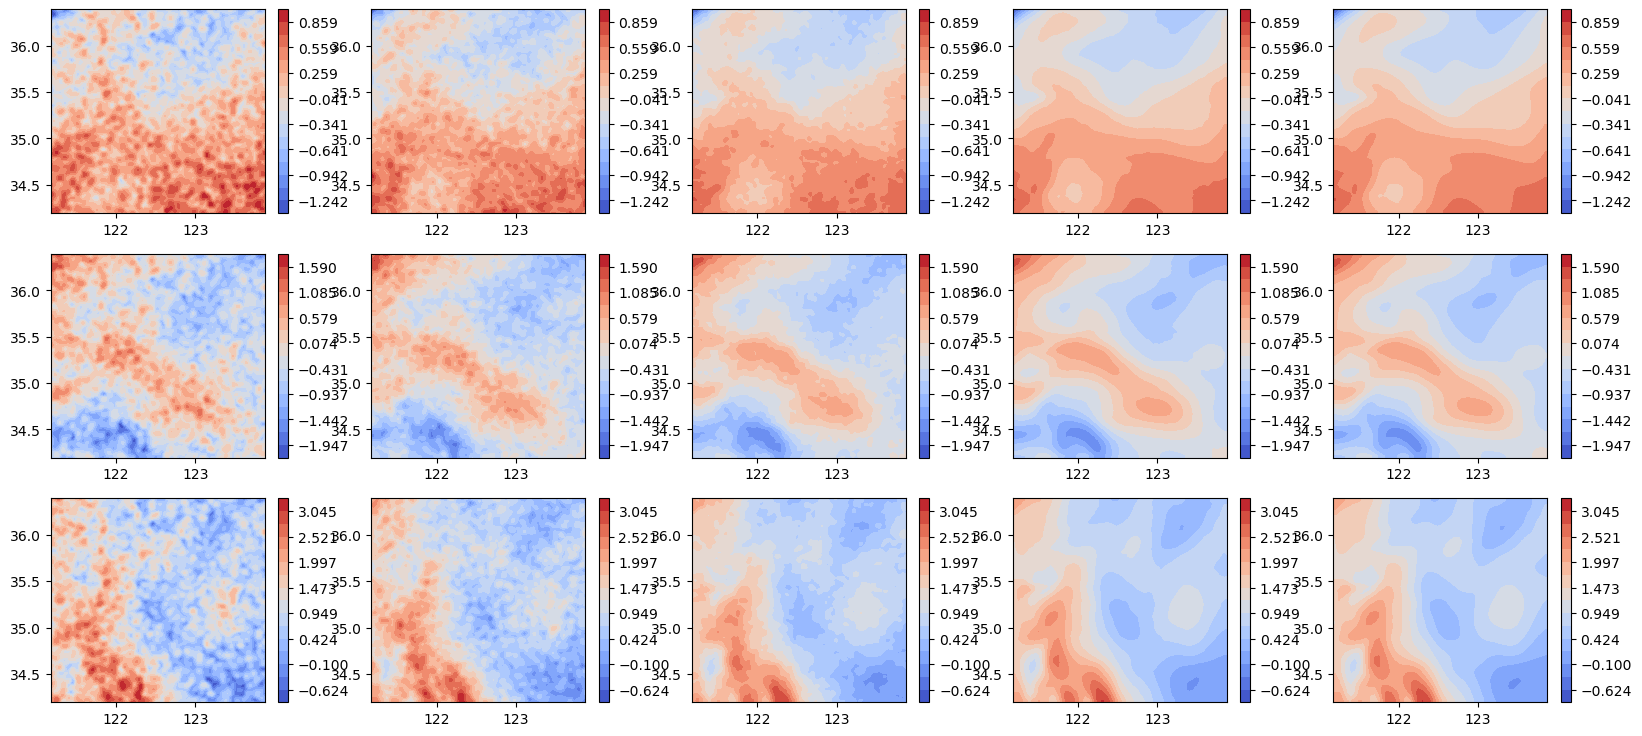

In [11]:
#values = grad_abs_norm(interpolated_grad_numpy)
values = interpolated_numpy
fig, axes = plt.subplots(3, 5, figsize=(20, 9))
vmin = np.nanmin(values,axis=(0,2,3));vmax = np.nanmax(values,axis=(0,2,3));
levels = np.stack([np.linspace(vmin[0], vmax[0], 17),
                   np.linspace(vmin[1], vmax[1], 17),
                   np.linspace(vmin[2], vmax[2], 17)], axis=0)
import matplotlib.colors as mcolors

red_cmap = mcolors.LinearSegmentedColormap.from_list(
    'truncated_coolwarm', 
    plt.cm.coolwarm(np.linspace(0.7, 1, 7))  
)

for row in range(3):
    for col in range(5):  
        ax = axes[row][col]      
        #contour = ax.contourf(lon, lat, np.squeeze(values[col,row,:,:]), levels=levels[row],
        #                           vmin=vmin[row], vmax=vmax[row], cmap=red_cmap)
        contour = ax.contourf(lon, lat, np.squeeze(values[col,row,:,:]), levels=levels[row],
                           vmin=vmin[row], vmax=vmax[row], cmap='coolwarm')
        fig.colorbar(contour, ax=ax, orientation='vertical')   
        #if col == 0:
        #    ax.plot([lon[80], lon[280], lon[280], lon[80], lon[80]],[lat[0], lat[0], lat[130], lat[130], lat[0]], 'r-', lw=2)
       
plt.show()

In [12]:
def saliency_map_PG(grad_list, result_list):
    #final_grad = grad_list.mean(axis=0)
    final_grad = np.nanmean(grad_list,axis=0)
    return final_grad, result_list[-1]

grad_numpy, result = saliency_map_PG(interpolated_grad_numpy, result_numpy)

In [13]:
grad0 = np.squeeze(grad_numpy[0,:,:])
result0 = np.squeeze(result[0,0,:,:])
ds = xr.Dataset({'grad': (['lat', 'lon'], grad0),
                 'result': (['lat', 'lon'], result0)},
                coords={'lat': lat, 'lon': lon})
ds.to_netcdf('grad7-0.nc')

grad1 = np.squeeze(grad_numpy[1,:,:])
result1 = np.squeeze(result[0,0,:,:])
ds = xr.Dataset({'grad': (['lat', 'lon'], grad1),
                 'result': (['lat', 'lon'], result1)},
                coords={'lat': lat, 'lon': lon})
ds.to_netcdf('grad7-1.nc')

grad2 = np.squeeze(grad_numpy[2,:,:])
result2 = np.squeeze(result[0,0,:,:])
ds = xr.Dataset({'grad': (['lat', 'lon'], grad2),
                 'result': (['lat', 'lon'], result2)},
                coords={'lat': lat, 'lon': lon})
ds.to_netcdf('grad7-2.nc')

In [ ]:
fig, axes = plt.subplots(3, 4, figsize=(16, 9))
blue_red = mcolors.LinearSegmentedColormap.from_list(
    'truncated_coolwarm', 
    plt.cm.coolwarm(np.linspace(0, 1, 7))  
)

clip_grad = grad_numpy
clip_grad[np.abs(clip_grad)<=0.0001] = np.nan
clip_grad = np.clip(clip_grad, -0.004, 0.004)

for row in range(3):
    for col in range(4):  
        ax = axes[row,col]  
        if col == 0:
            contour = ax.contourf(lon, lat, np.squeeze(interp_data[0,row,:,:].numpy()),
                                levels = 17, cmap='coolwarm')
            fig.colorbar(contour, ax=ax, orientation='vertical')
            
        elif col == 1:    
            contour = ax.contourf(lon, lat, np.squeeze(clip_grad[row,:,:]),cmap=blue_red,
                                  vmin=-0.004, vmax=0.004)
            fig.colorbar(contour, ax=ax, orientation='vertical')   

        elif col == 2 and row == 0:
            contour = ax.contourf(lon, lat, np.squeeze(denormalize_data(result,fake_doy)), levels = 17, 
                                  vmin = 2.8, vmax = 12.8, 
                                  cmap='coolwarm')
            fig.colorbar(contour, ax=ax, orientation='vertical')
#
        elif col == 3 and row == 0:
            contour = ax.contourf(lon, lat, np.squeeze(denormalize_data(label_data.numpy(),fake_doy)), levels = 17, 
                                  #vmin = 22.8, vmax = 26.3, 
                                  vmin = 2.8, vmax = 12.8, 
                                  cmap='coolwarm')
            fig.colorbar(contour, ax=ax, orientation='vertical')
        
        else:
            ax.axis('off')
       
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
#from matplotlib import rcParams

def channel_contribution(grad_numpy, method='abs_sum'):
    """
    :param grad_numpy: np.ndarray, shape = (C, H, W)
    :param method: 'abs_sum' | 'abs_mean' | 'signed_sum' | 'l2'
    :return: (contrib array, percent array)
    """
    if method == 'abs_sum':
        contrib = np.nansum(np.abs(grad_numpy), axis=(1, 2))
    elif method == 'abs_mean':
        contrib = np.nanmean(np.abs(grad_numpy), axis=(1, 2))
    elif method == 'signed_sum':
        contrib = np.nansum(grad_numpy, axis=(1, 2))
    elif method == 'l2':
        contrib = np.sqrt(np.nansum(grad_numpy ** 2, axis=(1, 2)))
    else:
        raise ValueError("Unknown method")
    
    total = np.nansum(np.abs(contrib))  # use abs to avoid negative percentages
    percent = contrib / total * 100
    return contrib, percent

def plot_channel_contribution(contrib, percent, labels, method='abs_sum', plot_type='pie'):
    #colors = ['#ff9999','#66b3ff','#99ff99']
    colors = [
        (252/255, 140/255, 90/255, 0.5),    # #2ca02c80 → Green (alpha=0.5)
        (75/255, 116/255, 178/255, 0.5),   # #ff7f0e80 → Orange (alpha=0.5)
        #(255/255, 223/255, 146/255, 0.5)     # #d6272880 → Red (alpha=0.5
        (144/255, 190/255, 224/255, 0.5),   # #1f77b480 → Blue (alpha=0.5)
    ]

    title_map = {
        'abs_sum': 'Absolute Sum',
        'abs_mean': 'Absolute Mean',
        'signed_sum': 'Signed Sum',
        'l2': 'L2 Norm'
    }

    plt.figure(figsize=(6, 5))
    if plot_type == 'pie':
        plt.pie(percent, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors)
        plt.title(f'Channel-wise Attribution ({title_map[method]})')
    elif plot_type == 'bar':
        plt.bar(labels, contrib, color=colors)
        for i, v in enumerate(contrib):
            plt.text(i, v, f'{percent[i]:.1f}%', ha='center', va='bottom')
        plt.title(f'Channel-wise Attribution ({title_map[method]})')
        plt.ylabel('Contribution')
    else:
        raise ValueError("plot_type must be 'pie' or 'bar'")
    plt.tight_layout()
    plt.show()
    #plt.savefig('f4-7pie.pdf', format='pdf', bbox_inches='tight', dpi=300)

labels = ['T', 'U', 'V']
contrib, percent = channel_contribution(grad_numpy, method='abs_sum')
plot_channel_contribution(contrib, percent, labels, method='abs_sum', plot_type='pie')


In [ ]:
# -----------------------------------------------------------------------------------
# Acknowledgment: 
# This file contains code adapted from the "LAM_Demo" package.
# Source: https://github.com/X-Lowlevel-Vision/LAM_Demo.git
# No explicit license was provided in the original repository.
# -----------------------------------------------------------------------------------